In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import PIL
import numpy as np
import matplotlib.pyplot as plt
from instaflow.pipeline_drag import RectifiedFlowStateMachine
from unidepth.models import UniDepthV2
from utils import (
    show_images_in_row,
    set_seed, 
    pred_unidepth, 
    unidepth_to_trimesh, 
    to_numpy_image,
    clean_mask_by_depth,
    compare_scene,
    transform_depth_map,
    MaskPainter,
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

pipe = RectifiedFlowStateMachine.from_pretrained("XCLiu/2_rectified_flow_from_sd_1_5", torch_dtype=torch.bfloat16,  device_map=DEVICE)
pipe.safety_checker = None

depth_model = UniDepthV2.from_pretrained("lpiccinelli/unidepth-v2-vitl14")
depth_model = depth_model.to(DEVICE)

/Data/yiming.chen/envs/py311/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Data/yiming.chen/InstaFlow/UniDepth/unidepth/utils/chamfer_distance.py:9: UserWarning: !! To run evaluation you need KNN. Please compile KNN: `cd unidepth/ops/knn with && bash compile.sh`.
  warnings.warn(


Cannot import NystromAttention, you can not run original UniDepth. UniDepthV2 is available.
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /Data/yiming.chen/huggingface/hub/models--XCLiu--2_rectified_flow_from_sd_1_5/snapshots/934962eb1054b67883fabb3e0860b851baf31142/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Data/yiming.chen/huggingface/hub/models--XCLiu--2_rectified_flow_from_sd_1_5/snapshots/934962eb1054b67883fabb3e0860b851baf31142/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/Data/yiming.chen/envs/py311/lib/python3.11/site-packages/diffusers/loaders/lora_pipeline.py:5501: FutureWarning: `LoraLoaderMixin` is deprecated and will be removed in version 1.0.0. LoraLoaderMixin is deprecated and this will be removed in a future version. Please use `StableDiffusionLoraLoaderMixin`, instead.
  deprecate("LoraLoaderMixin", "1.0.0", deprecation_message)


Not loading pretrained weights for backbone
EdgeGuidedLocalSSI reverts to a non cuda-optimized operation, you will experince large slowdown, please install it:  `cd ./unidepth/ops/extract_patches && bash compile.sh`


## Generate foreground and background images

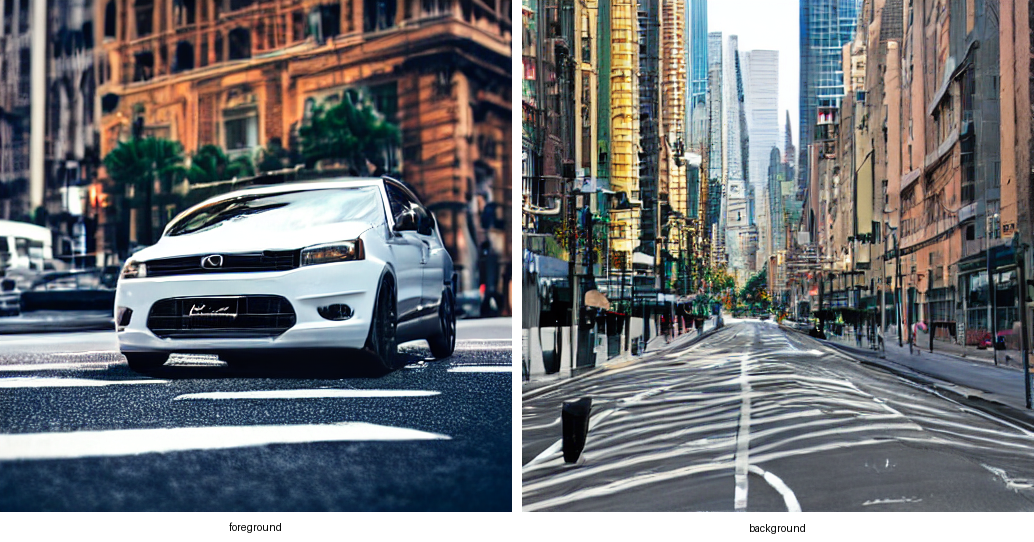

In [3]:
set_seed(512)
state_fg = pipe.prepare_state(
    prompt="A car in the city, high quality, detailed",
    num_inference_steps=50,
    guidance_scale=3,
    capture_all_intermediate_features=True,
)

state_fg = pipe.infer_from_state(state_fg, until=50)
img_fg = pipe.decode_latents(state_fg.latent)[0][0]

set_seed(25886)

state_bg = pipe.prepare_state(
    prompt="A city road, high quality, detailed",
    num_inference_steps=50,
    guidance_scale=1.5,
    capture_all_intermediate_features=False,
)

state_bg = pipe.infer_from_state(state_bg, until=50)
img_bg = pipe.decode_latents(state_bg.latent)[0][0]

show_images_in_row(
    [img_fg, img_bg ],
    ["foreground", "background"]
)

## Draw a mask

In [4]:
painter = MaskPainter(img_fg, brush_radius=20, fill_style="rgba(255, 255, 255, 0.8)")
painter.show()

Canvas(height=512, width=512)

## Method1: Blending

Mask tensor shape: torch.Size([1, 1, 512, 512]), dtype: torch.bfloat16
Control sample: hard blending
Method 1: Optimizing latent from step 20 to 25...
Starting blending optimization...
timestep 20...timestep 21...timestep 22...timestep 23...timestep 24...

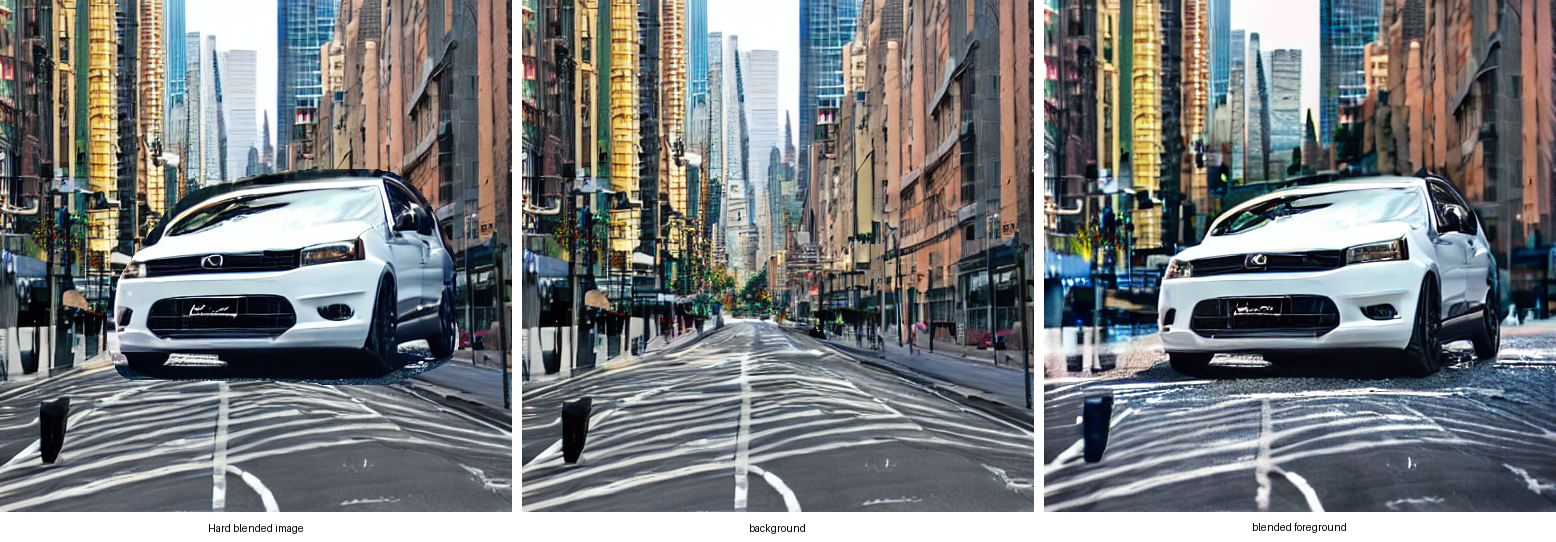

In [4]:
from instaflow.blend_transfer import BlendConfig, blend_with_fg_features

mask = painter.get_mask() # 0-1 numpy array dtype uint8
mask_tensor = torch.from_numpy(mask).to(device=state_bg.device, dtype=state_bg.latent.dtype)
if mask_tensor.ndim == 2:
    mask_tensor = mask_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
print(f"Mask tensor shape: {mask_tensor.shape}, dtype: {mask_tensor.dtype}")

########################### HARD BLENDING #################################
# Simple blending: mask * foreground + (1 - mask) * background
print("Control sample: hard blending")
fg_array = np.array(img_fg).astype(np.float32) / 255.0
bg_array = np.array(img_bg).astype(np.float32) / 255.0
mask_array = mask[:, :, np.newaxis]
blended_array = mask_array * fg_array + (1.0 - mask_array) * bg_array
blended_img = PIL.Image.fromarray((blended_array * 255).astype(np.uint8))

############################ SOFT BLENDING ################################

# Configs
config = BlendConfig(
    blend_start_step=20,
    blend_end_step=25,
    optim_steps_per_inference=10,
    lr=0.1,
    lamfg=0.01, # fg guidance scale
    lambg=0.001 # bg guidance scale
)

# Clone bg state as reference and regenerate with features
print(f"Method 1: Optimizing latent from step {config.blend_start_step} to {config.blend_end_step}...")
state_bg_ref = state_bg.clone()
state_bg_ref.capture_all_intermediate_features = True
state_bg_ref.intermediate_latents = []
state_bg_ref.reset()
state_bg_ref = pipe.infer_from_state(state_bg_ref, until=50)

print("Starting blending optimization...")
state_bg.reset()
state_bg = pipe.infer_from_state(state_bg, until=50,
    callback = blend_with_fg_features(pipe, state_fg, state_bg_ref, mask_tensor, config)
)
torch.cuda.empty_cache()
img_method1 = pipe.decode_latents(state_bg.latent)[0][0]

######################## ORIGINAL IMAGE #####################################
state_bg.reset()
state_bg = pipe.infer_from_state(state_bg, until=50, callback=None)
torch.cuda.empty_cache()
orig_img = pipe.decode_latents(state_bg.latent)[0][0]


################################ SHOW #######################################
show_images_in_row(
    [blended_img, orig_img, img_method1],
    ["Hard blended image", "background", "blended foreground"]
)

## Depth-aware transfer

In [11]:
from utils.widgets import MaskedDepthTransformWidget
mask = painter.get_mask()
predictions = pred_unidepth(img_fg, depth_model)
depth_transformer = MaskedDepthTransformWidget(img_fg, mask, predictions)
depth_transformer.show()

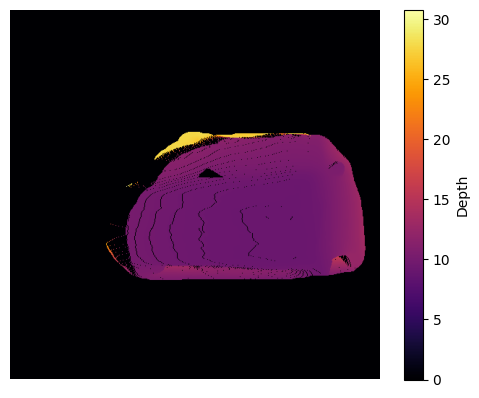

In [21]:
T = depth_transformer.get_transformation()
depth_new = transform_depth_map(predictions["depth"], predictions["intrinsics"], T, mask)
plt.imshow(depth_new, cmap="inferno")
plt.colorbar(label="Depth")
plt.axis("off")
plt.show()